In [1]:
import os, getpass
import logging

def _set_env(var: str):
    logging.warning("Calling setEnv")
    if not os.environ.get(var):
        logging.warning("API Key not found. Let's input")
        os.environ[var] = getpass.getpass(f"{var}: ")
    else:
        logging.warning("Found API Key in the environment")

_set_env("GOOGLE_API_KEY")

In [2]:
# pip install langchain-google-genai
from langchain_google_genai import ChatGoogleGenerativeAI

google_llm = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash",
    temperature=1.0,  # Gemini 3.0+ defaults to 1.0
    max_tokens=None,
    timeout=30,
    max_retries=1,
    # other params...
)



In [3]:
from langgraph.graph import MessagesState
from langchain_core.messages import SystemMessage

sys_msg = SystemMessage(content="You are a helpful assitant to respond to general purpose queries.")

# Here are we are creating an assitant Node. Remember Nodes are typically functions
# These functions take state as an argument and return a state
def assistant(state: MessagesState):
    return {"messages": [google_llm.invoke([sys_msg]+ state["messages"])]}

# At this point we have nodes, however no edges and graph yet.

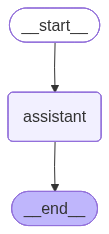

In [4]:
from langgraph.graph import START, StateGraph, END
from IPython.display import Image, display

builder = StateGraph(MessagesState)

builder.add_node("assistant", assistant)

# Start node is a special node that sends user input to the graph
builder.add_edge(START, "assistant")
builder.add_edge("assistant", END)

react_graph = builder.compile()

display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

In [14]:
# let's add another cell to ask a question
from langchain_core.messages import HumanMessage

messages = [HumanMessage(content="Capital of Sweden?")]
messages = react_graph.invoke({"messages" : messages})

for m in messages['messages']:    
    m.pretty_print()
    print(type(m.content))
    if isinstance(m.content, str):        
        print(m.content)
    elif isinstance(m.content, list):
        print(m.content[0]['text'])

# upto this point we demonstrated simple queries.
# What if you need to interact with some tool outside of an LLM. Next we will explore that.

================================ Human Message =================================

Capital of Sweden?
<class 'str'>
Capital of Sweden?
================================== Ai Message ==================================

[{'type': 'text', 'text': 'The capital of Sweden is **Stockholm**.', 'extras': {'signature': 'EswCCskCAQw51sdSr0pdWFucDZ5DWW69EpwrFSUdlF6md8xVbv1YF4w6WamtM24sBjk/LZ5UYHOyDsKi48DcDXDvjrC09mH7Sh/A/xtO8o7FHTlkk3wDCpmJDNwgQ5Loe7noOY/jEZf1l8zg6D1m3QFZsGqgNb8ruJlIcNRulap5z8KoR4MclqRA+k6jENnCEn3qjbZK5XzDzXORl9wwSexkoTD8aOi7x6eLdCi8LsDnY0CI85Uml+NH5sEJBlMF2rqLXJJIkFdGOOuxzgaN7+hPhO2l2fJAU4QMZL9FfzcQYYmglb5ASIm1Dho11e9zaReK2PGp9m9Ioxc3FgZX1MxDMsXqjvpit9Ru4TUhbGGMemOzG/Ti4St/Dtezp8Oi/6hk3xDJ0kGFF/loWdmuKTazLnX57FQjoKnOesVB20jIDl2PYU1Xye5WetycuHY='}}]
<class 'list'>
The capital of Sweden is **Stockholm**.
